In [31]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

  # Groq model SDK
from dotenv import load_dotenv
from typing import TypedDict, Annotated,Literal
from pydantic import BaseModel, Field,field_validator
import operator
import os

In [32]:
generator_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.9
)

evaluator_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

optimizer_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7
)

In [33]:
print(generator_llm.invoke("Write a funny tweet about deadlines").content)


"Deadlines are like in-laws: they're always showing up uninvited and making a mess, but somehow you manage to love them anyway (mostly because you're too stressed to get rid of them)."


In [34]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [35]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [36]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [37]:
def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(messages).content

    return {
        "tweet": response,
        "tweet_history": [response]
    }

In [38]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [39]:
def evaluate_tweet(state: TweetState):
    messages = [
        SystemMessage(
            content="You are a ruthless, no-laugh-given Twitter critic. "
                    "You evaluate tweets based on humor, originality, virality, and tweet format."
        ),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:
1. Originality
2. Humor
3. Punchiness
4. Virality Potential
5. Format

Auto-reject if:
- Question-answer format
- Over 280 characters
- Traditional setup-punchline joke
- Weak ending line

Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explanation
""")
    ]

    response = structured_evaluator_llm.invoke(messages)
    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
        "feedback_history": [response.feedback]
    }

In [40]:
def optimize_tweet(state: TweetState):
    messages = [
        SystemMessage(
            content="You punch up tweets for virality and humor based on given feedback."
        ),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet.
Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    return {
        "tweet": response,
        "iteration": state["iteration"] + 1,
        "tweet_history": [response]
    }

In [41]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

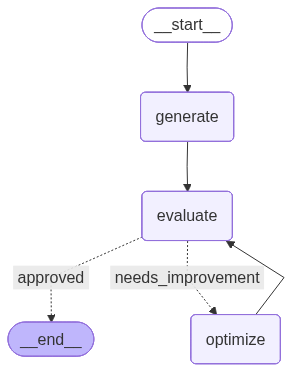

In [42]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [46]:
initial_state = {
    "topic": "India is very richest country in the world",
    "iteration": 1,
    "max_iteration": 5
}
# AFTER changing LLMs   # or StateGraph(...)
result = workflow.invoke(initial_state)
result



{'topic': 'India is very richest country in the world',
 'tweet': '"When people say India is the richest country, I think they mean... with richest being a synonym for \'poorest but still manages to survive with a 4G network\'. Just a theory. #IndiaRiches #SurvivalMode"',
 'evaluation': 'approved',
 'feedback': "This tweet is well-crafted with a unique perspective on India's 4G network. The humor is clever and the punchline is unexpected, making it engaging and entertaining. The use of hashtags adds to its virality potential. The format is concise and easy to read, making it perfect for Twitter. Overall, this tweet is well-written and effectively conveys its message.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"When people say India is the richest country, I think they mean... with richest being a synonym for \'poorest but still manages to survive with a 4G network\'. Just a theory. #IndiaRiches #SurvivalMode"'],
 'feedback_history': ["This tweet is well-crafted with a 